In [1]:
import os

api_key = os.getenv("OPENAI_API_KEY")

In [2]:
from langchain_openai import ChatOpenAI

# Initialize the ChatOpenAI with the API key and model
llm = ChatOpenAI(
    api_key=api_key,
    model="gpt-4o-mini"
)

In [3]:
# MCP imports
from mcp.client.sse import sse_client
from mcp import ClientSession
import asyncio

# Global MCP session
session = None

async def init_mcp():
    """Initialize MCP session"""
    global session
    read_stream, write_stream = await sse_client("http://localhost:8000/sse").__aenter__()
    session = ClientSession(read_stream, write_stream)
    await session.initialize()

async def get_mcp_tools():
    """Get tools from MCP server and create LangChain tool wrappers"""
    # List available tools from the server
    tools_response = await session.list_tools()
    
    langchain_tools = []
    for tool_info in tools_response.tools:
        # Create a tool function dynamically
        def make_tool(tool_name):
            @tool(name=tool_name, description=tool_info.description)
            def mcp_tool() -> str:
                # Create a new event loop for the tool call
                loop = asyncio.new_event_loop()
                asyncio.set_event_loop(loop)
                try:
                    async def call_tool():
                        result = await session.call_tool(tool_name, {})
                        return result.result
                    return loop.run_until_complete(call_tool())
                finally:
                    loop.close()
            return mcp_tool
        
        langchain_tools.append(make_tool(tool_info.name))
    
    return langchain_tools

# Initialize MCP connection
print("Connecting to MCP server...")
await init_mcp()
print("MCP connection established!")

# Get tools from MCP server
print("Loading tools from MCP server...")
tools = await get_mcp_tools()
print(f"Loaded {len(tools)} tools from server")
llm_with_tools = llm.bind_tools(tools)

Connecting to MCP server...


  + Exception Group Traceback (most recent call last):
  |   File "C:\Users\Praveen\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py", line 3697, in run_code
  |     await eval(code_obj, self.user_global_ns, self.user_ns)
  |   File "C:\Users\Praveen\AppData\Local\Temp\ipykernel_19384\1934835731.py", line 45, in <module>
  |     await init_mcp()
  |   File "C:\Users\Praveen\AppData\Local\Temp\ipykernel_19384\1934835731.py", line 12, in init_mcp
  |     read_stream, write_stream = await sse_client("http://localhost:8000/sse").__aenter__()
  |                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  |   File "c:\Users\Praveen\AppData\Local\Programs\Python\Python312\Lib\contextlib.py", line 210, in __aenter__
  |     return await anext(self.gen)
  |            ^^^^^^^^^^^^^^^^^^^^^
  |   File "c:\Users\Praveen\AppData\Local\Programs\Python\Python312\Lib\site-packages\mcp\client\sse.py", line 54, in sse_client
  |     async

In [ ]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

llm_with_tools = llm.bind_tools(mcp_tools)

# System message to define the assistant's role and specify when tool method to be invoked
sys_msg = SystemMessage("""You are an AI shop assistant. 
Use the ShopOpeningHours tool to check the shop's daily opening hours. 
Compare the current date and time to the schedule to determine if the shop is open or closed. 
Always provide a clear response with [Status: Open/Closed, CurrentDay: <day>] if Closed then display next opening hours. 
If asked about opening hours, return the full schedule for each day.""")

# Node as assistant - A python method with messagestate as input argument
def assistant(state: MessagesState):
    return { "messages": [llm_with_tools.invoke([sys_msg]+state["messages"])] }


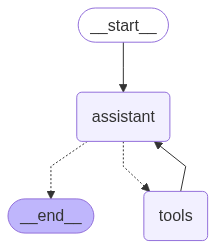

In [ ]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Initialize the StateGraph builder
builder = StateGraph(MessagesState)

# Add nodes for the assistant and tools
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Add edges between the nodes
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

react_graph = builder.compile()

display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
messages = [HumanMessage(content="is the shop open now? Give me next opening hours")]
messages = react_graph.invoke({"messages": messages})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

is the shop open now? Give me next opening hours
================================== Ai Message ==================================
Tool Calls:
  CurrentTime (3favks1kq)
 Call ID: 3favks1kq
  Args:
  ShopOpeningHours (yqpwhrz1y)
 Call ID: yqpwhrz1y
  Args:
================================= Tool Message =================================
Name: CurrentTime

2025-08-09 16:08:33.339757
================================= Tool Message =================================
Name: ShopOpeningHours

Monday: 10:00am to 8:00pm
                    Tuesday: 10:00am to 8:00pm
                    Wednesday: 10:00am to 8:00pm
                    Thursday: 10:00am to 8:00pm
                    Friday: 10:00am to 8:00pm
                    Saturday: 10:00am to 02:30pm
                    Sunday: 10:00am to 6:00pm
================================== Ai Message ==================================

.Status: Closed, CurrentDay: Saturday
